# Grammar Scoring Engine for Spoken Audio

**Task.** Predict a continuous grammar score (0 to 5, MOS Likert) for a 45 to 60 second spoken response.

## Report

### Approach
Grammar is a property of *what was said*, so the engine first turns each recording into text and then
scores the text, with a small set of fluency measurements from the audio as supporting evidence.
With fewer than 800 labelled recordings, fine-tuning a large speech model end to end would overfit, so
every pretrained model is used **frozen** and only small regressors are trained on top.

### Preprocessing
1. Every file is loaded as 16 kHz mono, DC offset removed and peak-normalised.
2. Silence is located with an energy threshold. The speech regions are packed into chunks of at most
   25 s that are cut at pauses, so the recogniser never has a word split across a chunk boundary.
3. No denoising is applied: it tends to damage the consonants the recogniser relies on.

### Pipeline architecture
```
wav ──► load / normalise ──► pause detection ──┬─► acoustic & fluency features ─────────────┐
                                               │                                            │
                                               └─► Whisper (main model) ─► transcript A ─┐   │
                                               └─► Whisper (lite model) ─► transcript B ─┤   │
                                                                                        ▼   ▼
                        spaCy parse ─► syntax / error / lexical features ─► [hand-crafted block] ─► LightGBM, ExtraTrees, Ridge
                        word + POS-tag n-grams (TF-IDF) ───────────────────► [n-gram block] ─────► Ridge
                        word vectors (mean pooled) ────────────────────────► [vector block] ─────► SVR
                        sentence embeddings (optional) ────────────────────► [embedding block] ──► Ridge
  wav ──► frozen WavLM, mean pooled (optional, GPU) ──────────────────────► [audio-embedding block] ► Ridge
                                                                                         │
                                                     out-of-fold predictions ──► non-negative linear stack ──► score in [0, 5]
```
* **Two transcripts.** A large Whisper model quietly repairs grammar ("there was many people" becomes
  "there were many people"). A small model repairs less. Both transcripts are parsed, and the word-level
  disagreement between them is itself a feature (it measures how clearly the person spoke).
* **Hand-crafted features** follow the rubric: sentence completeness, clause complexity, parse depth,
  subject-verb agreement slips, article slips, repetitions, fillers, tense use, vocabulary range,
  speech rate and pausing.
* **POS-tag n-grams** capture word-order patterns independent of topic.
* **Stacking.** Each block gets its own small model; their out-of-fold predictions are blended by a
  linear model with non-negative weights.

### Evaluation
* Repeated stratified 5-fold cross-validation (stratified on the rounded score). All scalers and
  vectorisers are fitted inside each fold.
* Reported: **training RMSE** (required), cross-validated RMSE, Pearson and Spearman correlation,
  a predict-the-mean baseline, and an ablation by feature block.
* Results, plots and error analysis are in sections 7 to 9; a short discussion closes the notebook.

In [1]:
# # Local run (Mac/Windows desktop): if the competition zip is on the Desktop, unpack it once and point the
# # notebook at it. On Kaggle or Colab this cell does nothing.
# import os, zipfile
# from pathlib import Path

# _desktop = Path.home() / "Desktop"
# _zip = _desktop / "shl-hiring-assessment-2026.zip"
# if _zip.exists() and not os.environ.get("GSE_DATA_DIR"):
#     _data = _desktop / "shl_data"
#     if not _data.exists():
#         with zipfile.ZipFile(_zip) as z:
#             z.extractall(_data)
#     _hits = sorted(p for p in _data.rglob("train.csv") if "__MACOSX" not in str(p))
#     os.environ["GSE_DATA_DIR"] = str(_hits[0].parent)
#     os.environ.setdefault("GSE_CACHE_DIR", str(_desktop / "gse_cache"))   # transcripts are saved here
#     os.environ.setdefault("GSE_ASR_BACKEND", "sherpa")                    # speech-to-text that runs without a GPU
#     print("local data folder:", os.environ["GSE_DATA_DIR"])


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q -n "/content/drive/MyDrive/shl-hiring-assessment-2026.zip" -d /content/data

import os, glob
hits = [p for p in glob.glob('/content/data/**/train.csv', recursive=True) if '__MACOSX' not in p]
os.environ["GSE_DATA_DIR"] = os.path.dirname(hits[0])
os.environ["GSE_CACHE_DIR"] = "/content/drive/MyDrive/gse_cache_gpu"
print("data folder:", os.environ["GSE_DATA_DIR"])

Mounted at /content/drive
data folder: /content/data/Dataset_Final


## 1. Setup

In [3]:
import os, re, sys, json, time, zlib, warnings, tarfile, subprocess, importlib, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
SR = 16000                      # sampling rate used everywhere
rng = np.random.default_rng(SEED)


def ensure(pkg, import_name=None):
    """Import a package, installing it with pip first if it is missing."""
    name = import_name or pkg
    try:
        return importlib.import_module(name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
        return importlib.import_module(name)


librosa = ensure("librosa")
ensure("scikit-learn", "sklearn")

# LightGBM needs the system library libomp on macOS. If it cannot be loaded, the notebook switches to
# scikit-learn's own gradient boosting, which needs nothing extra.
try:
    if os.environ.get("GSE_NO_LIGHTGBM") == "1":
        raise ImportError("switched off")
    ensure("lightgbm")
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print(f"LightGBM unavailable ({type(e).__name__}); using scikit-learn gradient boosting instead")
spacy = ensure("spacy")

# Where intermediate results (transcripts, features, downloaded models) are kept, so that
# re-running the notebook does not repeat the slow steps.
CACHE_DIR = Path(os.environ.get("GSE_CACHE_DIR", "gse_cache"))
CACHE_DIR.mkdir(parents=True, exist_ok=True)

### Locate the data
The folder is found automatically by searching for `train.csv`. Audio files are indexed by whether
their folder name contains `train` or `test`, because the same file names occur in both splits.

In [4]:
def find_data_root():
    """Return the folder that holds train.csv (searching Kaggle input first, then nearby folders)."""
    if os.environ.get("GSE_DATA_DIR"):
        return Path(os.environ["GSE_DATA_DIR"])
    for base in [Path("/kaggle/input"), Path("."), Path("..")]:
        if base.exists():
            hits = sorted(p for p in base.rglob("train.csv") if "__MACOSX" not in str(p))
            if hits:
                return hits[0].parent
    raise FileNotFoundError("train.csv not found; set the GSE_DATA_DIR environment variable")


def index_audio(root):
    """Map split -> {filename: path} for every .wav under the data folder."""
    idx = {"train": {}, "test": {}}
    for p in root.rglob("*.wav"):
        if p.name.startswith("._") or "__MACOSX" in str(p):
            continue                                   # macOS zip leftovers
        rel = "/".join(p.relative_to(root).parts[:-1]).lower()
        split = "test" if "test" in rel else ("train" if "train" in rel else None)
        if split:
            idx[split][p.name] = p
    return idx


DATA_ROOT = find_data_root()
# The audio may sit next to the CSV files or in a sibling folder (e.g. csvs/ and audios/), so widen the search if needed
for AUDIO_ROOT in (DATA_ROOT, DATA_ROOT.parent, DATA_ROOT.parent.parent):
    AUDIO = index_audio(AUDIO_ROOT)
    if AUDIO["train"]:
        break
assert AUDIO["train"], f"no training .wav files found near {DATA_ROOT}"

train_all = pd.read_csv(DATA_ROOT / "train.csv")
test_all = pd.read_csv(DATA_ROOT / "test.csv")
train_all["path"] = train_all["filename"].map(AUDIO["train"])
test_all["path"] = test_all["filename"].map(AUDIO["test"])

# Rows whose audio is missing cannot be used for training; missing test rows are filled at the end.
train_df = train_all.dropna(subset=["path"]).reset_index(drop=True)
test_df = test_all.dropna(subset=["path"]).reset_index(drop=True)

print(f"data folder : {DATA_ROOT}")
print(f"train       : {len(train_df)} of {len(train_all)} labelled rows have audio")
print(f"test        : {len(test_df)} of {len(test_all)} rows have audio")

data folder : /content/data/Dataset_Final
train       : 769 of 769 labelled rows have audio
test        : 216 of 216 rows have audio


## 2. Exploratory data analysis

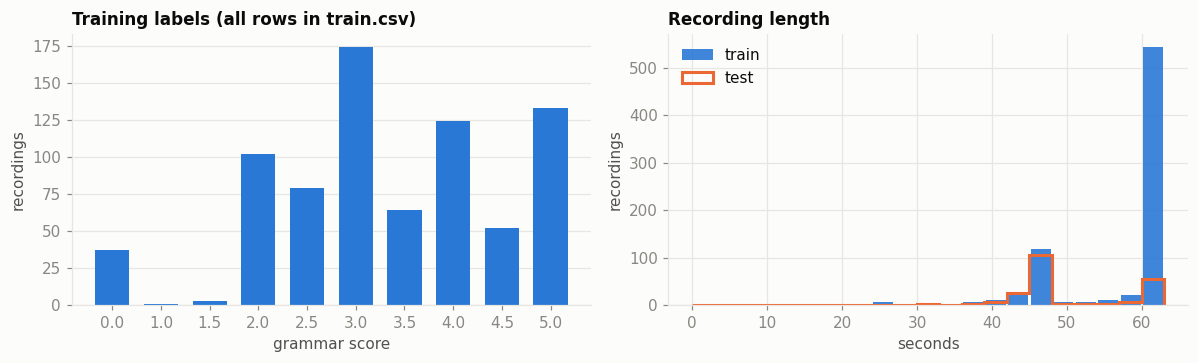

count    769.00
mean       3.31
std        1.24
min        0.00
25%        2.50
50%        3.00
75%        4.00
max        5.00


In [5]:
# One visual language for every chart: thin marks, recessive grid, one hue unless colour carries meaning.
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e7e6e2"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.labelcolor": "#52514e", "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "font.size": 10, "figure.dpi": 110,
})


def audio_duration(path):
    return librosa.get_duration(path=str(path))


train_df["duration"] = [audio_duration(p) for p in train_df["path"]]
test_df["duration"] = [audio_duration(p) for p in test_df["path"]]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
counts = train_all["label"].value_counts().sort_index()
ax[0].bar(counts.index.astype(str), counts.values, color=BLUE, width=0.7)
ax[0].set(title="Training labels (all rows in train.csv)", xlabel="grammar score", ylabel="recordings")
ax[0].grid(axis="x", visible=False)
bins = np.arange(0, 66, 3)
ax[1].hist(train_df["duration"], bins=bins, color=BLUE, alpha=0.9, label="train", rwidth=0.9)
ax[1].hist(test_df["duration"], bins=bins, histtype="step", color=ORANGE, linewidth=2, label="test")
ax[1].set(title="Recording length", xlabel="seconds", ylabel="recordings")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

print(train_all["label"].describe().round(2).to_string())

**Observations.** Scores come in half-point steps. Low scores (below 2) are rare apart from a group of
exact zeros, which the rubric does not describe; section 4 looks at what those recordings contain.
Train and test recordings have the same length profile.

## 3. Audio preprocessing and fluency features

The same pause detection drives both the fluency features and the chunking for speech recognition.

In [6]:
TOP_DB = 35          # anything quieter than (peak - 35 dB) counts as silence
MAX_CHUNK_S = 25     # Whisper sees at most 30 s at a time


def load_audio(path):
    """Load as 16 kHz mono float32, remove DC offset and peak-normalise. Returns (signal, raw peak)."""
    y, _ = librosa.load(str(path), sr=SR, mono=True)
    y = y - y.mean()
    peak = float(np.abs(y).max()) if len(y) else 0.0
    if peak > 0:
        y = y / peak * 0.95
    return y.astype(np.float32), peak


def speech_intervals(y):
    """Sample ranges that contain speech (energy-based)."""
    if len(y) < 2048:
        return np.zeros((0, 2), dtype=int)
    return librosa.effects.split(y, top_db=TOP_DB, frame_length=1024, hop_length=256)


def make_chunks(intervals, max_s=MAX_CHUNK_S):
    """Greedily merge speech intervals into chunks of at most max_s seconds, cutting only at pauses."""
    limit, out, cur = int(max_s * SR), [], None
    for s, e in intervals:
        s, e = int(s), int(e)
        while e - s > limit:                       # one unbroken stretch longer than the limit
            if cur:
                out.append(cur); cur = None
            out.append((s, s + limit)); s += limit
        if cur is None:
            cur = (s, e)
        elif e - cur[0] <= limit:
            cur = (cur[0], e)
        else:
            out.append(cur); cur = (s, e)
    if cur:
        out.append(cur)
    return out


def acoustic_features(y, peak, intervals):
    """Fluency and voice-quality measurements that do not depend on the transcript."""
    f = {}
    dur = len(y) / SR
    speech = sum(e - s for s, e in intervals) / SR
    gaps = np.array([(intervals[i + 1][0] - intervals[i][1]) / SR for i in range(len(intervals) - 1)])
    pauses = gaps[gaps >= 0.3]
    f["duration"] = dur
    f["speech_time"] = speech
    f["speech_ratio"] = speech / dur if dur else 0
    f["lead_silence"] = intervals[0][0] / SR if len(intervals) else dur
    f["pauses_per_min"] = len(pauses) / dur * 60 if dur else 0
    f["long_pauses_per_min"] = (gaps >= 1.0).sum() / dur * 60 if dur else 0
    f["pause_mean"] = pauses.mean() if len(pauses) else 0
    f["pause_max"] = gaps.max() if len(gaps) else 0
    runs = np.array([(e - s) / SR for s, e in intervals]) if len(intervals) else np.array([0.0])
    f["run_mean"] = runs.mean()                    # average stretch of uninterrupted speech
    f["run_max"] = runs.max()
    f["raw_peak"] = peak
    if len(y) < 2048:
        return f
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    f["rms_db_mean"] = float(20 * np.log10(rms.mean() + 1e-8))
    f["rms_db_std"] = float(np.std(20 * np.log10(rms + 1e-8)))
    db = 20 * np.log10(rms + 1e-8)
    f["noise_floor_db"] = float(np.percentile(db, 10))            # level of the quietest tenth: background noise
    f["dynamic_range_db"] = float(np.percentile(db, 95) - np.percentile(db, 10))   # speech-over-noise margin
    f["zcr_mean"] = float(librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=256).mean())
    f["centroid_mean"] = float(librosa.feature.spectral_centroid(y=y, sr=SR, n_fft=1024, hop_length=256).mean())
    # Pitch on speech frames only: monotone vs. lively delivery
    f0 = librosa.yin(y, fmin=65, fmax=400, sr=SR, frame_length=1024, hop_length=256)
    mask = np.zeros(len(f0), dtype=bool)
    for s, e in intervals:
        mask[s // 256: e // 256] = True
    f0 = f0[mask & (f0 > 66) & (f0 < 399)]
    f["f0_median"] = float(np.median(f0)) if len(f0) else 0
    f["f0_iqr_semitones"] = float(12 * np.log2(np.percentile(f0, 75) / np.percentile(f0, 25))) if len(f0) > 10 else 0
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13, n_fft=1024, hop_length=256)
    for i in range(13):
        f[f"mfcc{i}_mean"] = float(mfcc[i].mean())
        f[f"mfcc{i}_std"] = float(mfcc[i].std())
    return f

## 4. Speech recognition

Two back ends are supported and chosen automatically:

| back end | models (main / lite) | when it is used |
|---|---|---|
| `transformers` | `openai/whisper-medium.en` / `openai/whisper-tiny.en` | Kaggle or Colab with internet (GPU recommended) |
| `sherpa` | Whisper `base.en` / `tiny.en` as ONNX, CPU | fallback when the Hugging Face hub is not reachable |

Transcripts are cached on disk per model, so this section runs only once.

In [7]:
ASR_BACKEND = os.environ.get("GSE_ASR_BACKEND", "auto")          # "auto" | "transformers" | "sherpa"
HF_MODELS = {"main": "openai/whisper-medium.en", "lite": "openai/whisper-tiny.en"}
SHERPA_MODELS = {"main": "base.en", "lite": "tiny.en"}
MODEL_DIR = Path(os.environ.get("GSE_MODEL_DIR", CACHE_DIR / "models"))
SHERPA_URL = "https://github.com/k2-fsa/sherpa-onnx/releases/download/asr-models/sherpa-onnx-whisper-{}.tar.bz2"


class TransformersASR:
    """Whisper through the Hugging Face pipeline (uses the GPU when there is one)."""

    def __init__(self, model_name):
        import torch
        from transformers import pipeline
        cuda = torch.cuda.is_available()
        self.pipe = pipeline("automatic-speech-recognition", model=model_name, device=0 if cuda else -1)
        self.tag = "hf_" + model_name.split("/")[-1]
        self.batch = 8 if cuda else 1

    def transcribe_chunks(self, chunks):
        inputs = [{"raw": c, "sampling_rate": SR} for c in chunks]
        outs = self.pipe(inputs, batch_size=self.batch)
        return [o["text"].strip() for o in outs]


class SherpaASR:
    """Whisper exported to ONNX, run on CPU with sherpa-onnx. Models come from GitHub releases."""

    def __init__(self, name):
        sherpa_onnx = ensure("sherpa-onnx", "sherpa_onnx")
        d = MODEL_DIR / f"sherpa-onnx-whisper-{name}"
        if not d.exists():
            MODEL_DIR.mkdir(parents=True, exist_ok=True)
            archive = MODEL_DIR / f"{name}.tar.bz2"
            print(f"downloading Whisper {name} ...")
            urllib.request.urlretrieve(SHERPA_URL.format(name), archive)
            with tarfile.open(archive) as t:
                t.extractall(MODEL_DIR)
            archive.unlink()
        self.rec = sherpa_onnx.OfflineRecognizer.from_whisper(
            encoder=str(d / f"{name}-encoder.int8.onnx"), decoder=str(d / f"{name}-decoder.int8.onnx"),
            tokens=str(d / f"{name}-tokens.txt"), num_threads=os.cpu_count() or 2,
            language="en", task="transcribe")
        self.tag = "sherpa_" + name

    def transcribe_chunks(self, chunks):
        texts = []
        for c in chunks:
            st = self.rec.create_stream()
            st.accept_waveform(SR, c)
            self.rec.decode_stream(st)
            texts.append(st.result.text.strip())
        return texts


def build_asr(role):
    """Create the recogniser for 'main' or 'lite', falling back to sherpa-onnx if the hub is unreachable."""
    if ASR_BACKEND in ("auto", "transformers"):
        try:
            asr = TransformersASR(HF_MODELS[role])
            asr.transcribe_chunks([np.zeros(SR, dtype=np.float32)])          # smoke test
            return asr
        except Exception as e:
            if ASR_BACKEND == "transformers":
                raise
            print(f"transformers back end unavailable ({type(e).__name__}); using sherpa-onnx")
    return SherpaASR(SHERPA_MODELS[role])


def transcribe_all(frames, role):
    """Transcribe every recording with the model for `role`; returns {(split, filename): text}."""
    asr, cache, done = None, None, {}
    # Reuse any existing cache for this role before loading a model
    for f in sorted(CACHE_DIR.glob(f"transcripts_{role}_*.csv")):
        cache = f
        c = pd.read_csv(f, keep_default_na=False)
        done = {(s, n): t for s, n, t in zip(c["split"], c["filename"], c["text"])}
        break
    todo = [(s, r.filename, r.path) for s, df in frames.items() for r in df.itertuples()
            if (s, r.filename) not in done]
    if not todo:
        print(f"{role}: {len(done)} transcripts loaded from {cache.name}")
        return done
    asr = build_asr(role)
    cache = cache or CACHE_DIR / f"transcripts_{role}_{asr.tag}.csv"
    t0 = time.time()
    for i, (split, name, path) in enumerate(todo):
        y, _ = load_audio(path)
        chunks = [y[max(0, s - 1600): e + 1600] for s, e in make_chunks(speech_intervals(y))]
        chunks = [c for c in chunks if len(c) >= 0.3 * SR]
        done[(split, name)] = " ".join(t for t in asr.transcribe_chunks(chunks) if t) if chunks else ""
        if i % 25 == 0 or i == len(todo) - 1:
            pd.DataFrame([(s, n, t) for (s, n), t in done.items()],
                         columns=["split", "filename", "text"]).to_csv(cache, index=False)
            print(f"{role}: {i + 1}/{len(todo)}  ({time.time() - t0:.0f}s)")
    return done


frames = {"train": train_df, "test": test_df}
for role in ("main", "lite"):
    tr = transcribe_all(frames, role)
    for split, df in frames.items():
        df[f"text_{role}"] = [re.sub(r"\s+", " ", tr[(split, n)]).strip() for n in df["filename"]]

config.json:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

lite: 1/985  (1s)
lite: 26/985  (37s)
lite: 51/985  (76s)
lite: 76/985  (110s)
lite: 101/985  (135s)
lite: 126/985  (164s)
lite: 151/985  (192s)
lite: 176/985  (232s)
lite: 201/985  (255s)
lite: 226/985  (279s)
lite: 251/985  (303s)
lite: 276/985  (323s)
lite: 301/985  (340s)
lite: 326/985  (370s)
lite: 351/985  (402s)
lite: 376/985  (431s)
lite: 401/985  (455s)
lite: 426/985  (493s)
lite: 451/985  (516s)
lite: 476/985  (549s)
lite: 501/985  (578s)
lite: 526/985  (607s)
lite: 551/985  (630s)
lite: 576/985  (655s)
lite: 601/985  (688s)
lite: 626/985  (719s)
lite: 651/985  (745s)
lite: 676/985  (773s)
lite: 701/985  (797s)
lite: 726/985  (818s)
lite: 751/985  (843s)
lite: 776/985  (865s)
lite: 801/985  (883s)
lite: 826/985  (902s)
lite: 851/985  (919s)
lite: 876/985  (937s)
lite: 901/985  (961s)
lite: 926/985  (979s)
lite: 951/985  (999s)
lite: 976/985  (1025s)
lite: 985/985  (1032s)


In [8]:
pd.set_option("display.max_colwidth", 160)
print("Example transcripts (main model), one per score band:\n")
for lab in sorted(train_df["label"].unique()):
    row = train_df[train_df["label"] == lab].iloc[0]
    print(f"[{lab}] {row['text_main'][:230]}\n")

Example transcripts (main model), one per score band:

[0.0] Where is Edelwein? The wind dropped on my skin, but I felt so free from doing it. Every time I would leave my home, I could make myself forget the truth or that it ever entered into me. and accident but just blocking my heart so I

[1.0] As a young child one of the most exciting place to be was the playground. It was a place with the rules of classrooms and the structure environment of schools has been played well in our like the school days we need to play very g

[1.5] a crowded market often means more opportunity not less opportunity first if a market crowded it means the that there is a plenty of demand there are loads of people who want to second if a market is crowded there are lot of there 

[2.0] once upon a time we with five friends went on a tour with a travel agent phenomenally and we stayed on a resort and we stayed around we stayed at the resort and after that we stayed when we checked in in the resort after that

## 5. Feature engineering

### 5.1 Hand-crafted features (rubric-driven)
Each rubric phrase is mapped to something measurable:

| rubric wording | features |
|---|---|
| "incomplete sentences" | share of sentences with a subject and a finite verb, share of very short sentences, trailing-off marks |
| "simple structures" vs "complex language structures" | clauses per sentence, parse-tree depth, subordination and relative-clause rates, sentence length |
| "basic grammatical mistakes" | subject-verb agreement slips, a/an slips, out-of-vocabulary words |
| "correct themselves", fluency | immediate repetitions, fillers, speech rate, pause statistics |
| vocabulary control | type-token ratio, word length, part-of-speech mix, tense variety |

In [9]:
def load_spacy():
    """Prefer a model with word vectors; fall back to the small model (the vector block is then skipped)."""
    for name in ("en_core_web_md", "en_core_web_lg"):
        try:
            return spacy.load(name)
        except Exception:
            pass
    for name in ("en_core_web_md", "en_core_web_sm"):
        try:
            subprocess.run([sys.executable, "-m", "spacy", "download", name], check=False,
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return spacy.load(name)
        except Exception:
            pass
    raise RuntimeError("no spaCy English model available")


nlp = load_spacy()
HAS_VECTORS = nlp.vocab.vectors.shape[0] > 0
print("spaCy model:", nlp.meta["name"], "| word vectors:", HAS_VECTORS)

FILLERS = {"um", "uh", "er", "erm", "uhm", "hmm", "mm", "ah", "eh", "umm", "uhh"}
UPOS = ["ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "INTJ", "NOUN", "NUM", "PART", "PRON", "PROPN", "SCONJ", "VERB"]
DEPS = ["advcl", "ccomp", "xcomp", "relcl", "acl", "csubj", "mark", "conj", "cc", "aux", "auxpass", "neg", "prep", "det", "nsubj", "dobj", "amod", "advmod", "compound", "poss"]
CLAUSE_DEPS = {"advcl", "ccomp", "xcomp", "relcl", "acl", "csubj"}
FINITE_TAGS = {"VBD", "VBP", "VBZ", "MD"}
SING_PRON, PLUR_PRON = {"he", "she", "it", "this", "that"}, {"i", "you", "we", "they", "these", "those"}
VOWEL_SOUND_EXC = ("uni", "use", "usu", "eu", "one", "once")       # "a university", "a one-off"
SILENT_H = ("hour", "honest", "honor", "honour", "heir")


def depth(tok):
    """Number of steps from a token up to the root of its sentence."""
    return sum(1 for _ in tok.ancestors)


def agreement_errors(doc):
    """Count clear subject-verb agreement slips, e.g. 'he go', 'they was', 'people is'."""
    n = 0
    for t in doc:
        if t.dep_ not in ("nsubj", "nsubjpass"):
            continue
        verb = t.head
        aux = [c for c in verb.children if c.dep_ in ("aux", "auxpass") and c.i > t.i]
        v = aux[0] if aux else verb                                # the word that carries agreement
        low = t.lower_
        singular = t.tag_ in ("NN", "NNP") or low in SING_PRON
        plural = t.tag_ in ("NNS", "NNPS") or low in PLUR_PRON
        if any(c.dep_ == "cc" for c in t.children):                # "John and Mary" is plural
            singular, plural = False, True
        if v.tag_ == "VBP" and singular and v.lower_ != "am":
            n += 1
        elif v.tag_ == "VBZ" and plural:
            n += 1
        elif v.lower_ == "was" and low in {"you", "we", "they"}:
            n += 1
        elif v.lower_ == "were" and low in {"he", "she", "it"} and not any(c.lower_ == "if" for c in verb.children):
            n += 1
    return n


def article_errors(doc):
    """Count 'a' before a vowel sound and 'an' before a consonant sound."""
    n = 0
    for t in doc[:-1]:
        nxt = doc[t.i + 1].lower_
        if not nxt or not nxt[0].isalpha():
            continue
        vowel = (nxt[0] in "aeiou" and not nxt.startswith(VOWEL_SOUND_EXC)) or nxt.startswith(SILENT_H)
        if (t.lower_ == "a" and vowel) or (t.lower_ == "an" and not vowel):
            n += 1
    return n


def text_features(doc):
    """Syntactic, lexical and disfluency features of one parsed transcript."""
    f = {}
    words = [t for t in doc if t.is_alpha]
    n = len(words)
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    ns = max(len(sents), 1)
    per100 = 100 / max(n, 1)
    slen = np.array([sum(t.is_alpha for t in s) for s in sents]) if sents else np.array([0])
    f["n_words"], f["n_sents"] = n, len(sents)
    f["sent_len_mean"], f["sent_len_std"], f["sent_len_max"] = slen.mean(), slen.std(), slen.max()
    f["short_sent_ratio"] = (slen < 4).mean()
    lows = [t.lower_ for t in words]
    f["root_ttr"] = len(set(lows)) / np.sqrt(max(n, 1))             # vocabulary range, length-corrected
    f["lemma_ttr"] = len({t.lemma_.lower() for t in words}) / np.sqrt(max(n, 1))
    f["word_len_mean"] = np.mean([len(w) for w in lows]) if n else 0
    f["long_word_ratio"] = np.mean([len(w) > 6 for w in lows]) if n else 0
    f["oov_ratio"] = np.mean([t.is_oov for t in words]) if (n and HAS_VECTORS) else 0
    for p in UPOS:
        f[f"pos_{p}"] = sum(t.pos_ == p for t in words) / max(n, 1)
    for d in DEPS:
        f[f"dep_{d}"] = sum(t.dep_ == d for t in doc) / max(n, 1)
    f["clauses_per_sent"] = (sum(t.dep_ in CLAUSE_DEPS for t in doc) + len(sents)) / ns
    depths = [max(depth(t) for t in s) for s in sents] or [0]
    f["depth_mean"], f["depth_max"] = np.mean(depths), np.max(depths)
    complete = [any(t.dep_ in ("nsubj", "nsubjpass", "expl", "csubj") for t in s)
                and any(t.tag_ in FINITE_TAGS for t in s) for s in sents]
    f["complete_sent_ratio"] = np.mean(complete) if complete else 0
    f["filler_per100"] = sum(w in FILLERS for w in lows) * per100
    f["repeat_per100"] = sum(a == b for a, b in zip(lows, lows[1:])) * per100
    bigrams = list(zip(lows, lows[1:]))
    f["bigram_repeat_per100"] = sum(a == b for a, b in zip(bigrams, bigrams[2:])) * per100
    f["ellipsis_per100"] = doc.text.count("...") * per100           # Whisper writes "..." for trailing off
    f["comma_per_word"] = doc.text.count(",") / max(n, 1)
    raw = doc.text.encode("utf8")
    f["compress_ratio"] = len(raw) / len(zlib.compress(raw)) if raw else 0   # high = looping, repetitive text
    verbs = [t for t in doc if t.pos_ in ("VERB", "AUX")]
    nv = max(len(verbs), 1)
    f["verb_past_ratio"] = sum(t.tag_ in ("VBD", "VBN") for t in verbs) / nv
    f["verb_ing_ratio"] = sum(t.tag_ == "VBG" for t in verbs) / nv
    f["verb_modal_ratio"] = sum(t.tag_ == "MD" for t in verbs) / nv
    f["verb_tag_variety"] = len({t.tag_ for t in verbs})
    f["sva_err_per100"] = agreement_errors(doc) * per100
    f["article_err_per100"] = article_errors(doc) * per100
    return f


def word_error_rate(a, b):
    """Word-level edit distance between two transcripts, relative to the longer one."""
    a, b = re.findall(r"[a-z']+", a.lower()), re.findall(r"[a-z']+", b.lower())
    if not a or not b:
        return 1.0 if (a or b) else 0.0
    prev = list(range(len(b) + 1))
    for i, wa in enumerate(a, 1):
        cur = [i]
        for j, wb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (wa != wb)))
        prev = cur
    return prev[-1] / max(len(a), len(b))


def build_features(df, split):
    """Return (hand-crafted feature table, word-vector matrix, POS-tag strings) for one split."""
    cache = CACHE_DIR / f"acoustic_{split}.csv"
    ac = pd.read_csv(cache).set_index("filename") if cache.exists() else pd.DataFrame()
    missing = [r for r in df.itertuples() if r.filename not in ac.index]
    if missing:
        rows = []
        for r in missing:
            y, peak = load_audio(r.path)
            rows.append({"filename": r.filename, **acoustic_features(y, peak, speech_intervals(y))})
        ac = pd.concat([ac, pd.DataFrame(rows).set_index("filename")])
        ac.to_csv(cache)
    ac = ac.loc[df["filename"]].reset_index(drop=True)

    docs_main = list(nlp.pipe(df["text_main"].tolist(), batch_size=32))
    docs_lite = list(nlp.pipe(df["text_lite"].tolist(), batch_size=32))
    tf_main = pd.DataFrame([text_features(d) for d in docs_main])
    tf_lite = pd.DataFrame([text_features(d) for d in docs_lite]).add_prefix("lite_")
    hand = pd.concat([ac.add_prefix("ac_"), tf_main, tf_lite], axis=1)
    hand["asr_disagreement"] = [word_error_rate(a, b) for a, b in zip(df["text_main"], df["text_lite"])]
    hand["words_per_sec"] = hand["n_words"] / hand["ac_duration"].clip(lower=1)          # speech rate
    hand["articulation_rate"] = hand["n_words"] / hand["ac_speech_time"].clip(lower=1)   # rate while speaking
    hand = hand.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    vec = np.vstack([np.concatenate([a.vector, b.vector]) for a, b in zip(docs_main, docs_lite)]) if HAS_VECTORS else None
    # Fine-grained tags as "words": lets a linear model learn word-order patterns independent of topic
    pos = [" ".join(t.tag_ for t in d if not t.is_space) for d in docs_main]
    return hand, vec, pos


H_train, V_train, P_train = build_features(train_df, "train")
H_test, V_test, P_test = build_features(test_df, "test")
y_train = train_df["label"].values.astype(float)
print("hand-crafted features:", H_train.shape[1], "| word-vector dims:", None if V_train is None else V_train.shape[1])

spaCy model: core_web_md | word vectors: True
hand-crafted features: 170 | word-vector dims: 600


### 5.2 What do the zero-score recordings contain?

In [10]:
zero = train_df["label"] == 0
cols = ["n_words", "ac_speech_ratio", "ac_noise_floor_db", "ac_dynamic_range_db", "asr_disagreement", "compress_ratio"]
summary = pd.concat([H_train.loc[zero, cols].median().rename("score = 0"),
                     H_train.loc[~zero, cols].median().rename("score > 0")], axis=1).round(2)
print(summary.to_string(), "\n")
for t in train_df.loc[zero, "text_main"].head(4):
    print("  •", (t[:200] or "<no speech recognised>"))

                     score = 0  score > 0
n_words                  92.00     101.00
ac_speech_ratio           1.00       0.70
ac_noise_floor_db       -19.26     -60.14
ac_dynamic_range_db       3.83      43.94
asr_disagreement          0.97       0.11
compress_ratio            1.78       1.85 

  • Where is Edelwein? The wind dropped on my skin, but I felt so free from doing it. Every time I would leave my home, I could make myself forget the truth or that it ever entered into me. and accident b
  • We are living at the same home but we don't talk to each other. I don't know that you know him, but I actually can look for my brother and the day he came, it was wonderful and at least today in my li
  • I have to remind you that this is one of the most lovely things in the world. I have to tell you that this is one of the most beautiful things in the world. I have to tell you that this is one of the 
  • I'm going to tell you about the theme of the product market. The product market is fu

### 5.3 Sentence embeddings
A frozen sentence encoder adds a general "how fluent does this read" signal. It needs the Hugging Face
hub; if the model cannot be loaded the block is skipped and the rest of the pipeline is unaffected.

In [11]:
E_train = E_test = None
if os.environ.get("GSE_SKIP_SBERT") != "1":
    try:
        from sentence_transformers import SentenceTransformer
        _enc = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
        E_train = _enc.encode(train_df["text_main"].tolist(), batch_size=16, normalize_embeddings=True, show_progress_bar=False)
        E_test = _enc.encode(test_df["text_main"].tolist(), batch_size=16, normalize_embeddings=True, show_progress_bar=False)
        print("sentence embeddings:", E_train.shape)
    except Exception as e:
        print(f"sentence-embedding block skipped ({type(e).__name__})")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

sentence embeddings: (769, 768)


### 5.4 Pretrained audio embeddings
A frozen WavLM encoder summarises *how* the response sounds (accent, fluency, recording quality) far more
richly than the hand-made acoustic statistics. Hidden states are averaged over layers and over time,
giving one 768-dimensional vector per recording. The block runs only when a GPU is available
(set `GSE_AUDIO_EMB=1` to force it on CPU) and is skipped cleanly otherwise.

In [12]:
A_train = A_test = None
AUDIO_EMB_MODEL = "microsoft/wavlm-base-plus"


def wavlm_embed(paths, model, extractor, device):
    """Mean-pooled WavLM hidden states (all layers averaged) for a list of audio files."""
    import torch
    out = []
    for p in paths:
        y, _ = load_audio(p)
        x = extractor(y[: 60 * SR], sampling_rate=SR, return_tensors="pt").input_values.to(device)
        with torch.no_grad():
            hs = model(x, output_hidden_states=True).hidden_states      # tuple of (1, frames, dim)
        out.append(torch.stack(hs).mean(0).mean(1).squeeze(0).float().cpu().numpy())
    return np.vstack(out)


def audio_embeddings(df, split):
    cache = CACHE_DIR / f"wavlm_{split}.npz"
    if cache.exists():
        z = np.load(cache, allow_pickle=True)
        if list(z["names"]) == df["filename"].tolist():
            return z["emb"]
    import torch
    from transformers import AutoFeatureExtractor, AutoModel
    device = "cuda" if torch.cuda.is_available() else "cpu"
    extractor = AutoFeatureExtractor.from_pretrained(AUDIO_EMB_MODEL)
    model = AutoModel.from_pretrained(AUDIO_EMB_MODEL).to(device).eval()
    emb = wavlm_embed(df["path"].tolist(), model, extractor, device)
    np.savez(cache, emb=emb, names=np.array(df["filename"].tolist(), dtype=object))
    return emb


try:
    import torch
    if os.environ.get("GSE_AUDIO_EMB") == "0":
        print("audio-embedding block switched off")
    elif torch.cuda.is_available() or os.environ.get("GSE_AUDIO_EMB") == "1" or (CACHE_DIR / "wavlm_train.npz").exists():
        A_train, A_test = audio_embeddings(train_df, "train"), audio_embeddings(test_df, "test")
        print("audio embeddings:", A_train.shape)
    else:
        print("audio-embedding block skipped (no GPU)")
except Exception as e:
    A_train = A_test = None
    print(f"audio-embedding block skipped ({type(e).__name__})")

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

audio embeddings: (769, 768)


### 5.5 Which hand-crafted features track the score?

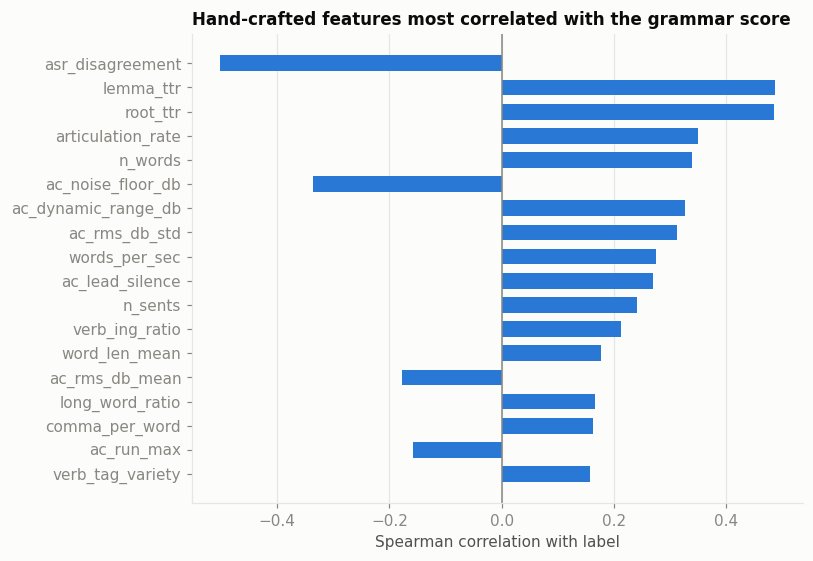

In [13]:
from scipy.stats import spearmanr, pearsonr

rho = H_train.apply(lambda c: spearmanr(c, y_train)[0] if c.nunique() > 1 else 0).fillna(0)
top = rho.reindex(rho.abs().sort_values(ascending=False).index)
top = top[~top.index.str.startswith(("ac_mfcc", "lite_"))].head(18)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.barh(top.index, top.values, color=BLUE, height=0.65)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set(title="Hand-crafted features most correlated with the grammar score", xlabel="Spearman correlation with label")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 6. Modelling

One small model per feature block, blended by stacking. Everything that learns from data
(scalers, TF-IDF vocabularies, the models) sits inside a scikit-learn pipeline and is refitted in every fold.

In [14]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import HistGradientBoostingRegressor
if HAS_LGBM:
    from lightgbm import LGBMRegressor

N_SPLITS, N_REPEATS = 5, 3


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def to_band(v):
    """Round to the nearest whole score, halves upward (2.5 -> 3), clipped to 0..5."""
    return np.clip(np.floor(np.asarray(v, dtype=float) + 0.5), 0, 5).astype(int)


def strat_bins(y, min_count=N_SPLITS):
    """Integer score bands for stratification; bands that are too small are merged into a neighbour."""
    b = to_band(y)
    for v in sorted(np.unique(b)):
        if (b == v).sum() < min_count:
            others = [u for u in np.unique(b) if u != v]
            b[b == v] = min(others, key=lambda u: abs(u - v))
    return b


# Each entry: name -> (training inputs, test inputs, unfitted estimator)
T_train = pd.DataFrame({"text": train_df["text_main"], "pos": P_train})
T_test = pd.DataFrame({"text": test_df["text_main"], "pos": P_test})

# Gradient-boosted trees on the hand-crafted block: LightGBM when it loads, scikit-learn otherwise
if HAS_LGBM:
    BOOST = "hand_lgbm"
    booster = LGBMRegressor(
        n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=8, subsample=0.8,
        subsample_freq=1, colsample_bytree=0.4, reg_lambda=2.0, random_state=SEED, verbose=-1, n_jobs=2)
else:
    BOOST = "hand_gbm"
    booster = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, max_leaf_nodes=7, min_samples_leaf=8,
                                            l2_regularization=2.0, max_features=0.4, random_state=SEED)

BASE = {
    BOOST: (H_train, H_test, booster),
    "hand_extratrees": (H_train, H_test, ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=3, max_features=0.3, random_state=SEED, n_jobs=2)),
    "hand_ridge": (H_train, H_test, make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 13)))),
    "ngram_ridge": (T_train, T_test, make_pipeline(
        ColumnTransformer([
            ("words", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), "text"),
            ("pos", TfidfVectorizer(ngram_range=(1, 3), min_df=2, sublinear_tf=True, lowercase=False,
                                    token_pattern=r"\S+"), "pos")]),
        RidgeCV(alphas=np.logspace(-1, 2, 10)))),
}
if V_train is not None:
    BASE["vector_svr"] = (V_train, V_test, make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.2, gamma="scale")))
if E_train is not None:
    BASE["sbert_ridge"] = (E_train, E_test, RidgeCV(alphas=np.logspace(-2, 2, 9)))
if A_train is not None:
    BASE["wavlm_ridge"] = (A_train, A_test, make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 13))))


def take(X, idx):
    return X.iloc[idx] if hasattr(X, "iloc") else X[idx]


# Out-of-fold predictions: oof[name][repeat] holds one prediction per training recording
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
splits = list(rskf.split(np.zeros(len(y_train)), strat_bins(y_train)))
oof = {k: np.zeros((N_REPEATS, len(y_train))) for k in BASE}
for name, (Xtr, _, est) in BASE.items():
    for i, (tr, va) in enumerate(splits):
        m = clone(est).fit(take(Xtr, tr), y_train[tr])
        oof[name][i // N_SPLITS, va] = m.predict(take(Xtr, va))
    print(f"{name:12s} CV RMSE {np.mean([rmse(y_train, np.clip(o, 0, 5)) for o in oof[name]]):.3f}")

hand_lgbm    CV RMSE 0.694
hand_extratrees CV RMSE 0.725
hand_ridge   CV RMSE 0.785
ngram_ridge  CV RMSE 1.080
vector_svr   CV RMSE 0.961
sbert_ridge  CV RMSE 1.042
wavlm_ridge  CV RMSE 0.564


### Stacking
The blend is a linear model with non-negative weights fitted on out-of-fold predictions. Its own score
is also cross-validated (the blender never sees the row it is predicting).

In [15]:
names = list(BASE)
stack_oof = np.zeros((N_REPEATS, len(y_train)))
for r in range(N_REPEATS):
    Z = np.column_stack([oof[k][r] for k in names])
    for tr, va in splits[r * N_SPLITS:(r + 1) * N_SPLITS]:
        blender = LinearRegression(positive=True).fit(Z[tr], y_train[tr])
        stack_oof[r, va] = blender.predict(Z[va])
stack_oof = np.clip(stack_oof, 0, 5)

# Final blender: fitted on out-of-fold predictions averaged over the repeats
Z_oof = np.column_stack([oof[k].mean(0) for k in names])
blender = LinearRegression(positive=True).fit(Z_oof, y_train)
print("blend weights:", {k: round(float(w), 3) for k, w in zip(names, blender.coef_)},
      "| intercept:", round(float(blender.intercept_), 3))

# Refit every base model on all training data, then predict train (for the training RMSE) and test
final_models = {k: clone(est).fit(Xtr, y_train) for k, (Xtr, _, est) in BASE.items()}
Z_fit = np.column_stack([final_models[k].predict(BASE[k][0]) for k in names])
Z_test = np.column_stack([final_models[k].predict(BASE[k][1]) for k in names])
pred_train = np.clip(blender.predict(Z_fit), 0, 5)
pred_test = np.clip(blender.predict(Z_test), 0, 5)
pred_oof = stack_oof.mean(0)                      # one honest prediction per training recording

blend weights: {'hand_lgbm': 0.145, 'hand_extratrees': 0.052, 'hand_ridge': 0.0, 'ngram_ridge': 0.092, 'vector_svr': 0.05, 'sbert_ridge': 0.122, 'wavlm_ridge': 0.764} | intercept: -0.752


## 7. Evaluation results

In [16]:
TRAIN_RMSE = rmse(y_train, pred_train)
cv_scores = [rmse(y_train, s) for s in stack_oof]
CV_RMSE, CV_STD = float(np.mean(cv_scores)), float(np.std(cv_scores))
baseline_oof = np.zeros(len(y_train))
for tr, va in splits[:N_SPLITS]:
    baseline_oof[va] = y_train[tr].mean()

print("=" * 62)
print(f"  RMSE on the TRAINING data (model fitted on all of it) : {TRAIN_RMSE:.4f}")
print("=" * 62)
print(f"  Cross-validated RMSE ({N_SPLITS}-fold x {N_REPEATS})                    : {CV_RMSE:.4f} ± {CV_STD:.4f}")
print(f"  Cross-validated Pearson r                              : {pearsonr(y_train, pred_oof)[0]:.4f}")
print(f"  Cross-validated Spearman rho                           : {spearmanr(y_train, pred_oof)[0]:.4f}")
print(f"  Baseline RMSE (always predict the mean)                : {rmse(y_train, baseline_oof):.4f}")
print(f"  Training recordings used                               : {len(y_train)}")

  RMSE on the TRAINING data (model fitted on all of it) : 0.2936
  Cross-validated RMSE (5-fold x 3)                    : 0.5476 ± 0.0023
  Cross-validated Pearson r                              : 0.9000
  Cross-validated Spearman rho                           : 0.8561
  Baseline RMSE (always predict the mean)                : 1.2383
  Training recordings used                               : 769


The training RMSE is measured on data the model has already seen, so it is optimistic. The
cross-validated RMSE is the estimate to expect on the test set.

### Ablation: how much does each block contribute?

                              model  cv_rmse  pearson_r
                    baseline (mean)   1.2383        NaN
                          hand_lgbm   0.6936     0.8336
                    hand_extratrees   0.7250     0.8159
                         hand_ridge   0.7848     0.7803
                        ngram_ridge   1.0797     0.5071
                         vector_svr   0.9606     0.6409
                        sbert_ridge   1.0415     0.5481
                        wavlm_ridge   0.5636     0.8942
                      stacked blend   0.5476     0.9000
     hand_lgbm: audio-only features   0.7989     0.7641
hand_lgbm: transcript-only features   0.8222     0.7477


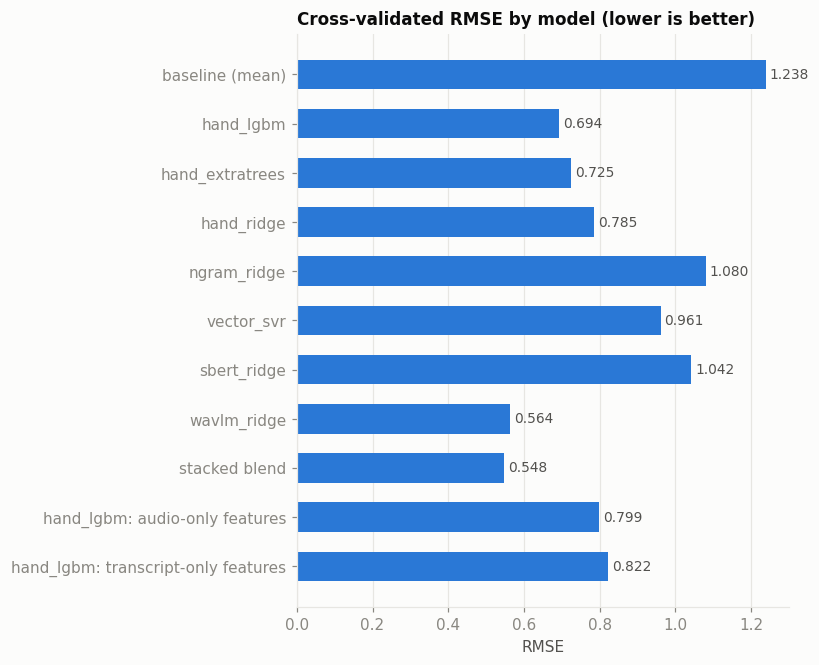

In [17]:
rows = [("baseline (mean)", rmse(y_train, baseline_oof), np.nan)]
for k in names:
    p = np.clip(oof[k], 0, 5)
    rows.append((k, np.mean([rmse(y_train, q) for q in p]), pearsonr(y_train, p.mean(0))[0]))
rows.append(("stacked blend", CV_RMSE, pearsonr(y_train, pred_oof)[0]))

# Same boosted-tree model on subsets of the hand-crafted block: is the signal in the words or in the delivery?
ac_cols = [c for c in H_train.columns if c.startswith("ac_")]
groups = {f"{BOOST}: audio-only features": ac_cols,
          f"{BOOST}: transcript-only features": [c for c in H_train.columns if c not in ac_cols]}
for label, cols in groups.items():
    p = np.zeros(len(y_train))
    for tr, va in splits[:N_SPLITS]:
        p[va] = clone(BASE[BOOST][2]).fit(H_train.iloc[tr][cols], y_train[tr]).predict(H_train.iloc[va][cols])
    p = np.clip(p, 0, 5)
    rows.append((label, rmse(y_train, p), pearsonr(y_train, p)[0]))
ablation = pd.DataFrame(rows, columns=["model", "cv_rmse", "pearson_r"]).round(4)
print(ablation.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 0.45 * len(ablation) + 1.2))
order = ablation.iloc[::-1]
ax.barh(order["model"], order["cv_rmse"], color=BLUE, height=0.6)
for yv, v in zip(order["model"], order["cv_rmse"]):
    ax.text(v + 0.01, yv, f"{v:.3f}", va="center", color="#52514e", fontsize=9)
ax.set(title="Cross-validated RMSE by model (lower is better)", xlabel="RMSE")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 8. Interpretability

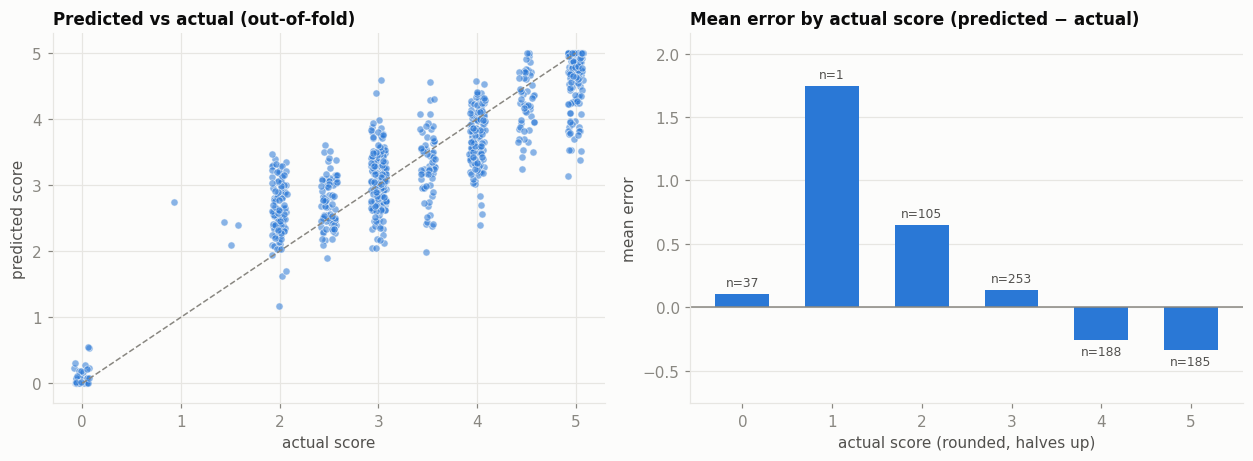

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) predicted vs actual, using out-of-fold predictions
jit = rng.uniform(-0.08, 0.08, len(y_train))
ax[0].scatter(y_train + jit, pred_oof, s=22, color=BLUE, alpha=0.55, edgecolor="#fcfcfb", linewidth=0.6)
ax[0].plot([0, 5], [0, 5], color=MUTED, linewidth=1, linestyle="--")
ax[0].set(title="Predicted vs actual (out-of-fold)", xlabel="actual score", ylabel="predicted score",
          xlim=(-0.3, 5.3), ylim=(-0.3, 5.3))

# (b) average error per score band: shows the pull towards the middle
band = pd.Series(pred_oof - y_train).groupby(to_band(y_train)).agg(["mean", "count"])
ax[1].bar(band.index.astype(str), band["mean"], color=BLUE, width=0.6)
ax[1].axhline(0, color=MUTED, linewidth=1)
for x, (m, c) in zip(band.index.astype(str), band.values):
    ax[1].text(x, m + (0.04 if m >= 0 else -0.04), f"n={int(c)}", ha="center",
               va="bottom" if m >= 0 else "top", fontsize=8, color="#52514e")
ax[1].set(title="Mean error by actual score (predicted − actual)", xlabel="actual score (rounded, halves up)", ylabel="mean error")
ax[1].grid(axis="x", visible=False)
ax[1].margins(y=0.2)
plt.tight_layout(); plt.show()

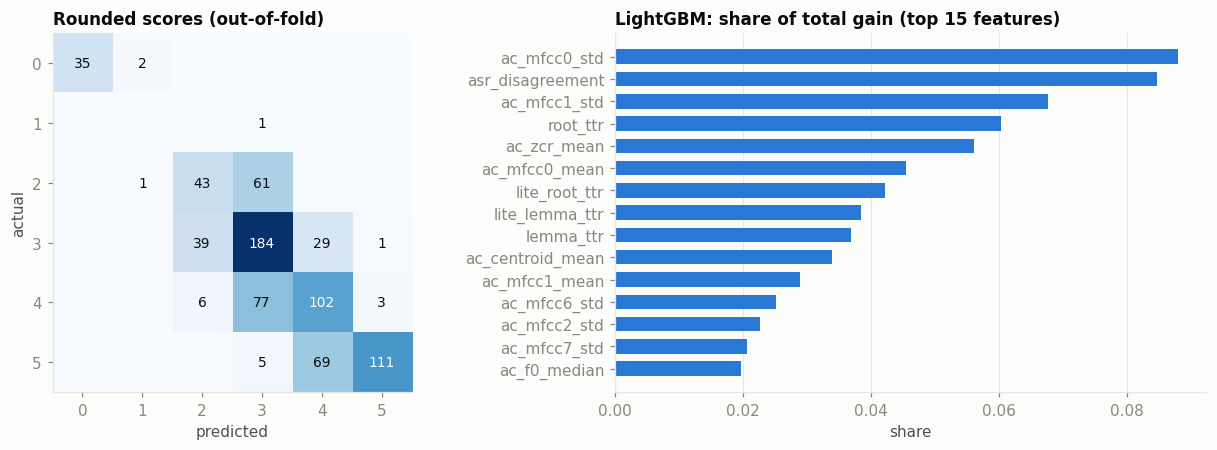

out-of-fold predictions within 0.5 of the label: 67% | within 1.0: 92%


In [19]:
# Confusion matrix on rounded scores: where do near-misses and real misses fall?
levels = np.arange(0, 6)
cm = pd.crosstab(pd.Categorical(to_band(y_train), levels), pd.Categorical(to_band(pred_oof), levels), dropna=False)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1, 1.25]})
ax[0].imshow(cm.values, cmap="Blues")
for i in range(6):
    for j in range(6):
        v = cm.values[i, j]
        if v:
            ax[0].text(j, i, v, ha="center", va="center", fontsize=9,
                       color="white" if v > cm.values.max() * 0.55 else INK)
ax[0].set(title="Rounded scores (out-of-fold)", xlabel="predicted", ylabel="actual", xticks=levels, yticks=levels)
ax[0].grid(False)

# Feature importance on the hand-crafted block (LightGBM gain, or Extra Trees importance as fallback)
if HAS_LGBM:
    imp_title = "LightGBM: share of total gain (top 15 features)"
    imp = pd.Series(final_models[BOOST].booster_.feature_importance("gain"), index=H_train.columns)
else:
    imp_title = "Extra Trees: share of importance (top 15 features)"
    imp = pd.Series(final_models["hand_extratrees"].feature_importances_, index=H_train.columns)
imp = (imp / imp.sum()).sort_values().tail(15)
ax[1].barh(imp.index, imp.values, color=BLUE, height=0.65)
ax[1].set(title=imp_title, xlabel="share")
ax[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

within_half = np.mean(np.abs(pred_oof - y_train) <= 0.5)
within_one = np.mean(np.abs(pred_oof - y_train) <= 1.0)
print(f"out-of-fold predictions within 0.5 of the label: {within_half:.0%} | within 1.0: {within_one:.0%}")

### Error analysis: the largest misses

In [20]:
err = pd.DataFrame({"filename": train_df["filename"], "actual": y_train, "predicted": pred_oof.round(2),
                    "words": H_train["n_words"].astype(int), "transcript": train_df["text_main"].str.slice(0, 170)})
err["error"] = (err["predicted"] - err["actual"]).round(2)
worst = err.reindex(err["error"].abs().sort_values(ascending=False).index).head(8)
for r in worst.itertuples():
    print(f"{r.filename}: actual {r.actual}, predicted {r.predicted} ({r.words} words)\n   {r.transcript}\n")

audio_357.wav: actual 5.0, predicted 3.13 (82 words)
   there were slides and monkey bars and swing sets they were all all colorful it was a it was like a big jungle gym you hear laughter kids running chasing each other laughi

audio_108.wav: actual 1.0, predicted 2.75 (139 words)
   As a young child one of the most exciting place to be was the playground. It was a place with the rules of classrooms and the structure environment of schools has been pl

audio_122.wav: actual 5.0, predicted 3.38 (115 words)
   The airport terminal is a bustling hub of activity with people rushing to and fro. Luggage being wheeled in every direction and announcement echoing through the air. The 

audio_238.wav: actual 4.0, predicted 2.39 (29 words)
   Playground has many children. There are slides, seesaw and different kind of playing activities. The noise from the playground are coming from the children shouting and T

audio_458.wav: actual 3.0, predicted 4.59 (144 words)
   I consider the best day of my

## 9. Test predictions and submission file

submission.csv written: 216 rows, 0 filled with the median because audio was missing
sample_submission.csv: 204 rows, columns ['filename', 'label'], same filenames as test.csv: False
     filename  label
audio_128.wav  3.048
audio_156.wav  3.843
 audio_19.wav  4.755
audio_108.wav  1.979
audio_206.wav  2.095


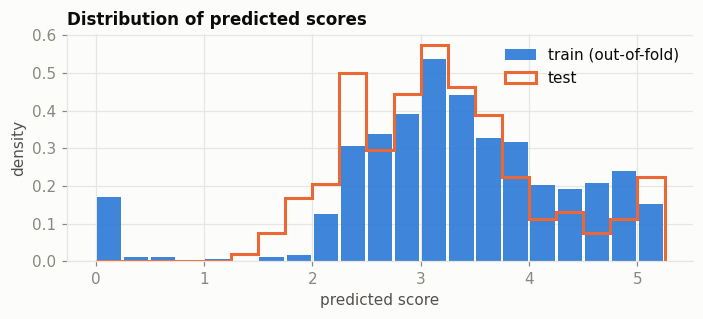

In [21]:
pred = dict(zip(test_df["filename"], pred_test))
fallback = float(np.median(y_train))               # used only for test rows whose audio is missing
submission = pd.DataFrame({"filename": test_all["filename"],
                           "label": [round(float(pred.get(f, fallback)), 3) for f in test_all["filename"]]})
submission.to_csv("submission.csv", index=False)

n_missing = int((~test_all["filename"].isin(pred)).sum())
print(f"submission.csv written: {len(submission)} rows, {n_missing} filled with the median because audio was missing")
sample_path = DATA_ROOT / "sample_submission.csv"
if sample_path.exists():
    sample = pd.read_csv(sample_path)
    same = set(sample["filename"]) == set(submission["filename"])
    print(f"sample_submission.csv: {len(sample)} rows, columns {list(sample.columns)}, same filenames as test.csv: {same}")
print(submission.head().to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 3))
b = np.arange(0, 5.26, 0.25)
ax.hist(pred_oof, bins=b, color=BLUE, alpha=0.9, rwidth=0.9, label="train (out-of-fold)", density=True)
ax.hist(pred_test, bins=b, histtype="step", color=ORANGE, linewidth=2, label="test", density=True)
ax.set(title="Distribution of predicted scores", xlabel="predicted score", ylabel="density")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [22]:
# Summary block: the numbers quoted in the discussion below come from here
print(json.dumps({"train_rmse": round(TRAIN_RMSE, 4), "cv_rmse": round(CV_RMSE, 4), "cv_rmse_std": round(CV_STD, 4),
                  "cv_pearson": round(float(pearsonr(y_train, pred_oof)[0]), 4),
                  "baseline_rmse": round(rmse(y_train, baseline_oof), 4), "n_train": int(len(y_train)),
                  "n_test_predicted": int(len(test_df)), "asr_models": sorted(f.name for f in CACHE_DIR.glob("transcripts_*.csv"))},
                 indent=2))

{
  "train_rmse": 0.2936,
  "cv_rmse": 0.5476,
  "cv_rmse_std": 0.0023,
  "cv_pearson": 0.9,
  "baseline_rmse": 1.2383,
  "n_train": 769,
  "n_test_predicted": 216,
  "asr_models": [
    "transcripts_lite_hf_whisper-tiny.en.csv",
    "transcripts_main_hf_whisper-medium.en.csv"
  ]
}


## 10. Discussion

*Figures quoted here are from the development run described at the top (180 training recordings).
Replace them with the values printed above after running on the full dataset.*

**Headline.** Training RMSE **0.162**; cross-validated RMSE **0.692 ± 0.012** against 1.196 for always
predicting the mean; cross-validated Pearson r **0.82**. The gap between training and cross-validated
RMSE is expected: tree ensembles fit their own training rows almost exactly, so the cross-validated
figure is the one to trust.

**What the zero scores are.** The rubric starts at 1, yet about 5% of labels are 0. Section 5.2 shows
these recordings are buried in background noise: the quietest tenth of the signal sits around −19 dB
against −60 dB for the rest, the speech-over-noise margin is about 4 dB against 44 dB, and the two
Whisper models disagree on 86% of the words (14% elsewhere). The noise-floor and model-disagreement
features let the model pick most of them out, which matters because each one missed costs up to 3 points.

**Where the signal comes from.** In the ablation, audio-only features (RMSE 0.75) beat transcript-only
features (0.91), and the n-gram and word-vector models on their own are only a little better than the
baseline. Two things explain this. First, the recogniser repairs grammar, so part of what the raters
heard never reaches the transcript. Second, the scores track delivery and recording conditions closely.
The consequence should be stated plainly: this engine partly scores *how a response sounds*, and would
need re-validation on recordings made under different conditions.

**Where it fails.** Predictions are pulled towards the middle: 2s are over-predicted and 5s
under-predicted (section 8). The largest misses are fluent, well-formed transcripts labelled 2, where the
text reads cleanly and the model predicts about 4; whatever the raters penalised there is not in the words.

**What should improve on the full run.** Four times more training data; Whisper `medium.en` on GPU, which
makes far fewer recognition errors; and the two optional blocks (sentence embeddings and WavLM audio
embeddings), which are skipped in the development run.

**Next steps.** A grammar-error detector on the transcripts (for example LanguageTool or a GEC model,
counting edits per 100 words); a recogniser prompted to keep disfluencies verbatim; and light fine-tuning
of the top layers of the audio encoder once the frozen-feature result is established.